# Unit 3, Day 7: ML Team Challenge
## Comprehensive Regression & Classification Review

**Instructor:** Abishek Ganesh

---

Welcome to the ML Team Challenge! Today you'll work with your group to:

1. **Practice explaining ML concepts** (interview prep!)
2. **Build regression models** to predict medical insurance costs
3. **Build classification models** to predict high-cost vs low-cost patients
4. **Compare and evaluate** your models
5. **Learn from each other** through code review and discussion

---

### Ground Rules

- **Cameras ON** - This is collaborative work, not solo work in silence
- **Everyone has their own notebook** - Download this from Slack and fill it out yourself
- **Work together as a team** - Discuss approaches, ask questions, help each other debug
- **Compare results** - Come together to see who found the best model and why
- **This is teamwork practice** - Learning to collaborate on ML projects is just as important as building the models themselves

---

### Important: No AI Tools

**Do NOT use ChatGPT, Claude, Gemini, or any other AI assistant to answer the interview questions or write code for this assignment.** Using AI to generate your answers completely defeats the purpose of this exercise - it won't help you learn, and it certainly won't help you in a real job interview.

The goal here is to build **your** skills:
- For the interview questions: Struggle through explaining concepts in your own words. That struggle is where learning happens.
- For the coding sections: You are **welcome and encouraged** to reference code from our previous notebooks. Look at how we built models before and use that as a guide to write your own code here. This is how real developers work - by building on patterns they've seen before.

Writing the code yourself - even if you're referencing examples - builds the physical muscle memory and mental patterns you need. Copying from AI doesn't.

---

### Your Group

Write your group members' names here:

- Person 1: Sean
- Person 2: David
- Person 3: Erick
- Person 4: _______________
- Person 5: _______________ (if applicable)

---

# PART 1: Interview Warm-Up

---

## Why Are We Doing This?

Many of you are looking to find a job in AI after this bootcamp - and **interview prep is going to be key**. But even if you're not looking for a job right now, being able to properly explain technical concepts is a hugely valuable asset in any career.

Here's the truth: **I want you to struggle.** I want you to have trouble trying to explain things that you think you understand. That's how you're going to grow - by working with each other collaboratively, supporting each other as you try to articulate very complicated topics that you've only just learned.

**If you can explain overfitting to a teammate, you understand it. If you stumble through it, now you know what to study. Either way, you win.**

---

### How This Works

Each person has been assigned **2 questions**. When it's your turn:

1. **Read your question out loud** to the group
2. **Give your best answer** - it doesn't have to be perfect!
3. **Group members can add** to your answer or gently correct
4. **Move to the next person**

If your whole group is stuck on a question, that's okay! Note it down and move on - that's a topic to review later.

---

### Person 1 Questions

**Question 1A:** What's the difference between supervised and unsupervised learning? Give an example of each.

**Question 1B:** Explain the bias-variance tradeoff. How does model complexity relate to each?

---

### Person 2 Questions

**Question 2A:** What does R² tell you? What's a "good" R² score?

**Question 2B:** When would you use Ridge vs Lasso regularization? What problem do they both solve?

---

### Person 3 Questions

**Question 3A:** What's the difference between precision and recall?

**Question 3B:** You're building a model to detect cancer. Would you optimize for precision or recall? Why?

---

### Person 4 Questions

**Question 4A:** What is overfitting? How do you detect it?

**Question 4B:** Why might a model with 95% accuracy still be terrible? Give a specific example.

---

### Person 5 Questions

*(If your group has only 4 people, Person 1 takes these questions)*

**Question 5A:** Why do we split data into training and test sets?

**Question 5B:** You trained a Decision Tree with no max_depth limit. It has 100% training accuracy but 65% test accuracy. What happened and how would you fix it?

---

### Interview Warm-Up Reflection

Before moving on, discuss as a group:

- Which question was hardest for your group to answer?
- What concept do you need to review more?

**Note your thoughts here:**

I need to review Ridge L2 and Lasso L1 regularization.
When is a high r2 not a good.
Review Bias-Variance tradeoffs.

---

# PART 2: The ML Challenge

---

## The Dataset: Medical Insurance Costs

You'll be working with a real-world dataset containing information about medical insurance customers and their charges.

**Features:**
- `age`: Age of the patient
- `sex`: Gender (male/female)
- `bmi`: Body Mass Index
- `children`: Number of children/dependents
- `smoker`: Smoking status (yes/no)
- `region`: US region (northeast, southeast, southwest, northwest)

**Target:**
- `charges`: Medical insurance charges (continuous - for regression)
- `high_cost`: Whether charges are above median (binary - for classification)

---

## How This Part Works

**Sections A & B (Data Exploration & Preparation):**
- The code is already written for you
- **Run each cell** and observe the output
- **Discuss as a group:** What do the visualizations tell you? What features seem important? What patterns do you notice?
- Everyone should understand the data before moving on

**Sections C & D (Model Building):**
- **Split into pairs** - Pair A works on regression, Pair B works on classification
- **You write the code** using what you've learned in Days 3-6
- Goal: Build the best performing model you can!

**Section E (Group Discussion):**
- Come back together as a full group
- Share your results, discuss what worked, compare models

---

## Your Mission

⭐ **THE GOAL:** Build the best performing models you can. This means:
- Try multiple algorithms
- Tune hyperparameters
- Compare metrics fairly
- Be able to explain WHY your best model won

🏆 **Challenge:** Can your pair beat the baseline by at least 10%?

---

## Setup: Import Libraries

Run this cell to load all the tools you'll need.

In [47]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning - Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Machine Learning - Model Selection & Evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    mean_squared_error, r2_score,  # Regression metrics
    accuracy_score, precision_score, recall_score, f1_score,  # Classification metrics
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# For nicer plots
plt.style.use('seaborn-v0_8-whitegrid')

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


---

## Load the Dataset

In [48]:
# Load the Medical Insurance dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head(10)

Dataset shape: (1338, 7)

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


---

## Section A: Shared Data Exploration (ALL)

### 📋 Instructions: Run the code and discuss as a group

The code in this section is already written. Your job is to:
1. **Run each cell** 
2. **Look at the output** - What do you see?
3. **Discuss with your group** - What patterns are emerging? What features look important?

Don't move on until everyone understands the data!

In [49]:
# Basic statistics
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [50]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [51]:
# Look at the categorical columns
print("Sex distribution:")
print(df['sex'].value_counts())
print("\nSmoker distribution:")
print(df['smoker'].value_counts())
print("\nRegion distribution:")
print(df['region'].value_counts())

Sex distribution:
sex
male      676
female    662
Name: count, dtype: int64

Smoker distribution:
smoker
no     1064
yes     274
Name: count, dtype: int64

Region distribution:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


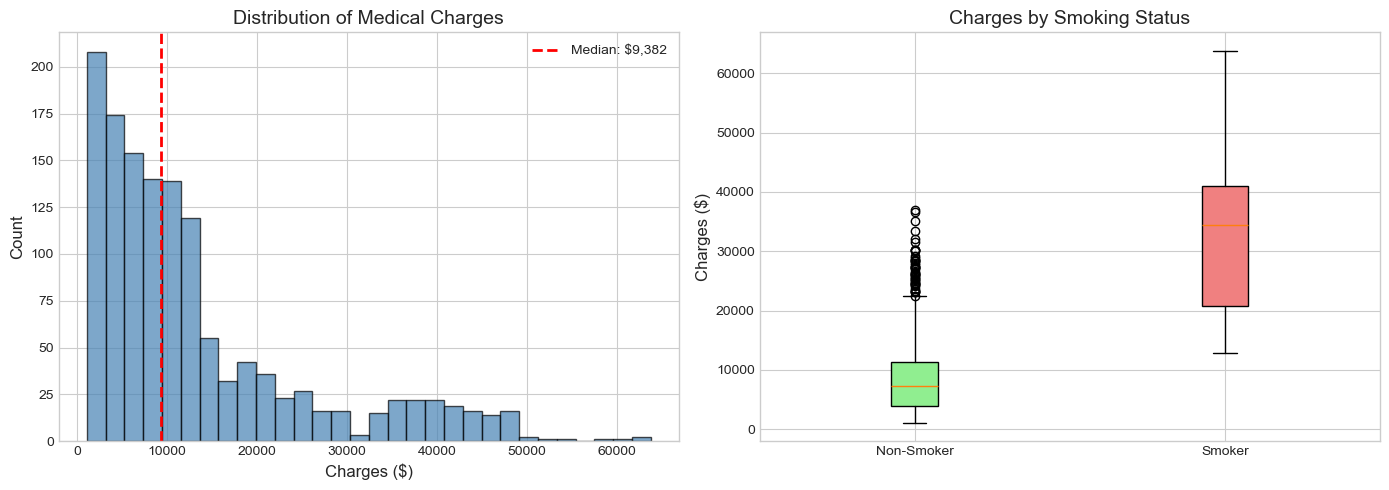


Charges Statistics:
  Mean: $13,270.42
  Median: $9,382.03
  Std: $12,110.01


In [13]:
# Visualize the target variable (charges)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of charges
axes[0].hist(df['charges'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Charges ($)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Distribution of Medical Charges', fontsize=14)
axes[0].axvline(df['charges'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: ${df["charges"].median():,.0f}')
axes[0].legend()

# Box plot by smoker status
smoker_groups = [df[df['smoker']=='no']['charges'], df[df['smoker']=='yes']['charges']]
bp = axes[1].boxplot(smoker_groups, labels=['Non-Smoker', 'Smoker'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
axes[1].set_ylabel('Charges ($)', fontsize=12)
axes[1].set_title('Charges by Smoking Status', fontsize=14)

plt.tight_layout()
plt.show()

print(f"\nCharges Statistics:")
print(f"  Mean: ${df['charges'].mean():,.2f}")
print(f"  Median: ${df['charges'].median():,.2f}")
print(f"  Std: ${df['charges'].std():,.2f}")

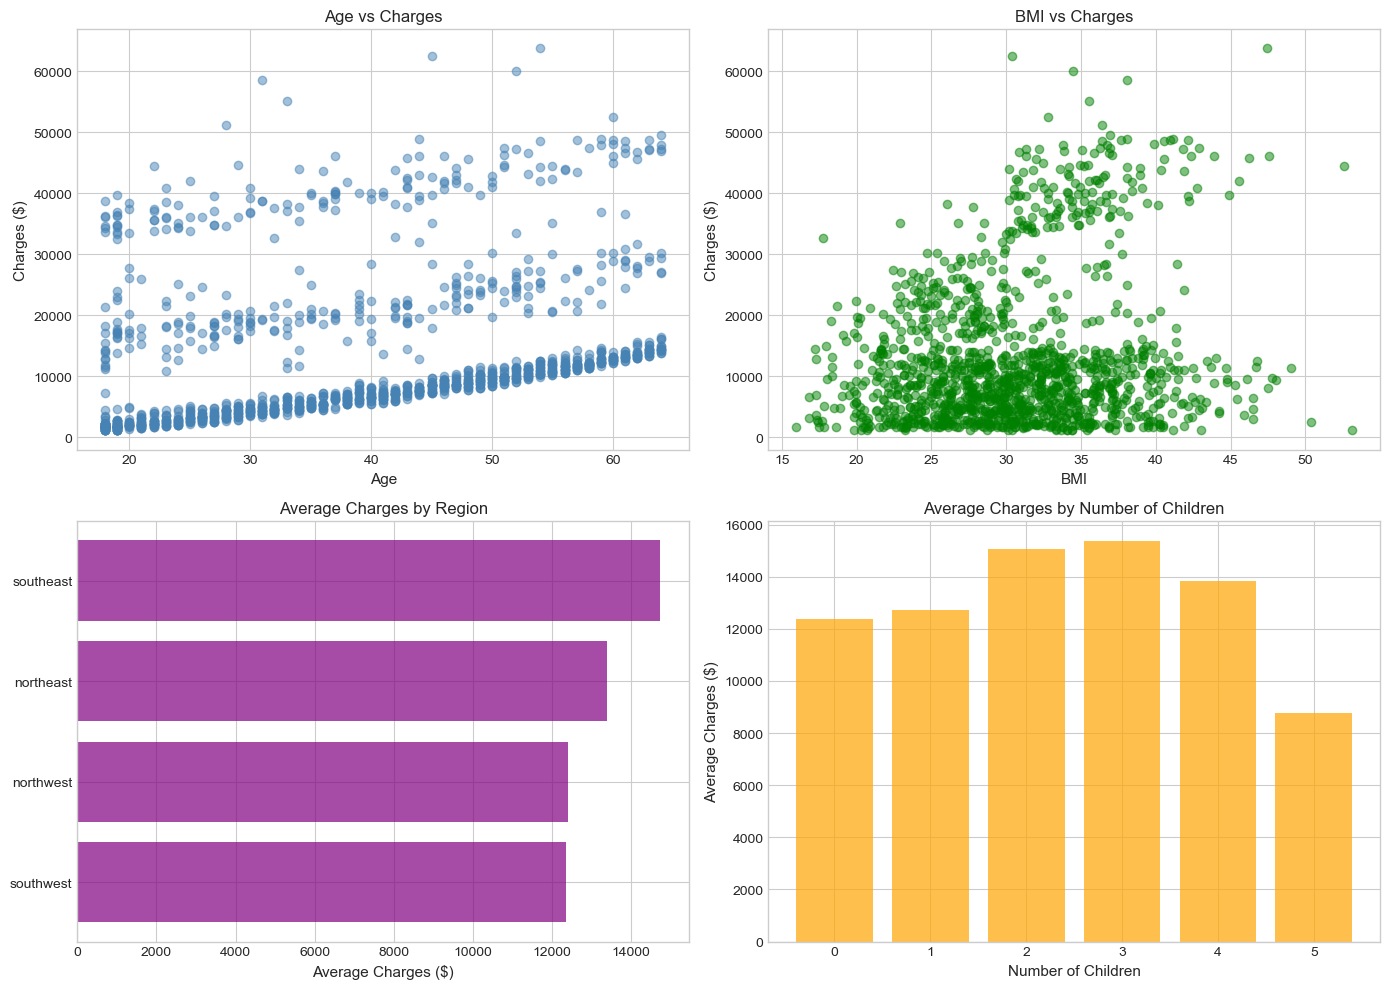

In [14]:
# Explore relationships between features and charges
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age vs Charges
axes[0, 0].scatter(df['age'], df['charges'], alpha=0.5, c='steelblue')
axes[0, 0].set_xlabel('Age', fontsize=11)
axes[0, 0].set_ylabel('Charges ($)', fontsize=11)
axes[0, 0].set_title('Age vs Charges', fontsize=12)

# BMI vs Charges
axes[0, 1].scatter(df['bmi'], df['charges'], alpha=0.5, c='green')
axes[0, 1].set_xlabel('BMI', fontsize=11)
axes[0, 1].set_ylabel('Charges ($)', fontsize=11)
axes[0, 1].set_title('BMI vs Charges', fontsize=12)

# Average charges by region
region_charges = df.groupby('region')['charges'].mean().sort_values()
axes[1, 0].barh(region_charges.index, region_charges.values, color='purple', alpha=0.7)
axes[1, 0].set_xlabel('Average Charges ($)', fontsize=11)
axes[1, 0].set_title('Average Charges by Region', fontsize=12)

# Average charges by number of children
children_charges = df.groupby('children')['charges'].mean()
axes[1, 1].bar(children_charges.index, children_charges.values, color='orange', alpha=0.7)
axes[1, 1].set_xlabel('Number of Children', fontsize=11)
axes[1, 1].set_ylabel('Average Charges ($)', fontsize=11)
axes[1, 1].set_title('Average Charges by Number of Children', fontsize=12)

plt.tight_layout()
plt.show()

### Group Discussion: Feature Selection

Based on your exploration, discuss with your group:

**Which 2-3 features do you think will be most predictive of charges? Why?**

*Write your group's thoughts here:*

1. Higher charges as you get older.
2. Higher charges if you are a smoker.
3. Higher charges generally the more obese you are.

---

## Section B: Converting Regression → Classification

### 📋 Instructions: Run the code and discuss as a group

This section shows you how to convert a regression problem into a classification problem - a critical skill you'll use in your capstone projects!

### Why Convert?

Sometimes stakeholders don't need an exact number - they just need to know **"high"** or **"low"**.

Examples:
- Instead of "this patient will cost $45,231" → "this patient is HIGH COST"
- Instead of "this house is worth $387,000" → "this house is ABOVE MARKET"
- Instead of "churn probability is 0.73" → "this customer is AT RISK"

**⭐ IMPORTANT:** You'll be doing something very similar in your individual capstone projects soon, so this is a critical skill to have.

In [15]:
# ============================================================
# Converting a Regression Target → Classification Target
# ============================================================
# We'll create a binary target: high_cost = 1 if charges > median, else 0
#
# This is a common real-world technique! Sometimes stakeholders 
# don't need an exact number - they just need to know "high" or "low"
#
# ⭐ IMPORTANT: You'll be doing something very similar in your 
# individual capstone projects soon, so this is a critical skill to have.
# ============================================================

median_charges = df['charges'].median()
df['high_cost'] = (df['charges'] > median_charges).astype(int)

print(f"Median charges: ${median_charges:,.2f}")
print(f"\nThis becomes our threshold for 'high cost' vs 'low cost'")
print(f"\nClass distribution:")
print(f"  High cost patients (1): {df['high_cost'].sum()} ({df['high_cost'].mean()*100:.1f}%)")
print(f"  Low cost patients (0):  {(df['high_cost']==0).sum()} ({(df['high_cost']==0).mean()*100:.1f}%)")
print(f"\nPerfectly balanced! (By design - we used the median)")

Median charges: $9,382.03

This becomes our threshold for 'high cost' vs 'low cost'

Class distribution:
  High cost patients (1): 669 (50.0%)
  Low cost patients (0):  669 (50.0%)

Perfectly balanced! (By design - we used the median)


In [16]:
# Verify our new column
df[['charges', 'high_cost']].head(10)

,charges,high_cost
0,16884.92400,1
1,1725.55230,0
2,4449.46200,0
3,21984.47061,1
4,3866.85520,0
5,3756.62160,0
6,8240.58960,0
7,7281.50560,0
8,6406.41070,0
9,28923.13692,1


---

## Data Preparation (Shared)

Before splitting into pairs, let's prepare the features that BOTH pairs will use.

In [17]:
# Convert categorical variables to numeric
df_model = df.copy()

# Convert sex: female=0, male=1
df_model['sex_numeric'] = (df_model['sex'] == 'male').astype(int)

# Convert smoker: no=0, yes=1
df_model['smoker_numeric'] = (df_model['smoker'] == 'yes').astype(int)

# One-hot encode region (creates 4 columns, we'll drop one to avoid multicollinearity)
region_dummies = pd.get_dummies(df_model['region'], prefix='region', drop_first=True)
df_model = pd.concat([df_model, region_dummies], axis=1)

print("New columns created:")
print(df_model[['sex', 'sex_numeric', 'smoker', 'smoker_numeric']].head())
print("\nRegion dummies:")
print(region_dummies.head())

New columns created:
      sex  sex_numeric smoker  smoker_numeric
0  female            0    yes               1
1    male            1     no               0
2    male            1     no               0
3    male            1     no               0
4    male            1     no               0

Region dummies:
   region_northwest  region_southeast  region_southwest
0             False             False              True
1             False              True             False
2             False              True             False
3              True             False             False
4              True             False             False


In [20]:
# Define the feature columns we'll use
feature_columns = ['age', 'sex_numeric', 'bmi', 'children', 'smoker_numeric', 
                   'region_northwest', 'region_southeast', 'region_southwest']

# Create feature matrix
X = df_model[feature_columns]

# Create target variables
y_regression = df_model['charges']      # For Pair A (regression)
y_classification = df_model['high_cost'] # For Pair B (classification)

print(f"Feature matrix shape: {X.shape}")
print(f"Features: {feature_columns}")
print(f"\nRegression target (charges): {y_regression.shape}")
print(f"Classification target (high_cost): {y_classification.shape}")

Feature matrix shape: (1338, 8)
Features: ['age', 'sex_numeric', 'bmi', 'children', 'smoker_numeric', 'region_northwest', 'region_southeast', 'region_southwest']

Regression target (charges): (1338,)
Classification target (high_cost): (1338,)


In [21]:
# ============================================================
# IMPORTANT: Both pairs use the SAME random_state!
# This ensures fair comparison between regression and classification results
# ============================================================

RANDOM_STATE = 42  # Don't change this!

# Split for REGRESSION (Pair A)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_regression, test_size=0.2, random_state=RANDOM_STATE
)

# Split for CLASSIFICATION (Pair B)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_classification, test_size=0.2, random_state=RANDOM_STATE
)

print("Data split complete!")
print(f"\nTraining samples: {len(X_train_reg)}")
print(f"Testing samples: {len(X_test_reg)}")
print(f"\nBoth pairs are using the SAME train/test split (random_state={RANDOM_STATE})")

Data split complete!

Training samples: 1070
Testing samples: 268

Both pairs are using the SAME train/test split (random_state=42)


In [22]:
# Scale the features (needed for some models)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_reg)  # Fit on training data
X_test_scaled = scaler.transform(X_test_reg)        # Transform test data

# Convert back to DataFrame for easier use
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_columns, index=X_train_reg.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_columns, index=X_test_reg.index)

print("Features scaled!")
print("\nNote: Use scaled data for Linear/Logistic Regression and Ridge/Lasso")
print("Decision Trees don't need scaling, but it won't hurt.")

Features scaled!

Note: Use scaled data for Linear/Logistic Regression and Ridge/Lasso
Decision Trees don't need scaling, but it won't hurt.


---

# 🔀 TIME TO SPLIT INTO PAIRS AND START CODING!

---

## Now YOU Write the Code

Up until now, the code was provided for you. **From here on, you write the code yourself.**

Use what you learned in Days 3-6 as reference. Look back at those notebooks for patterns and syntax.

---

## Pair Assignments

| Pair | Members | Task | Section |
|------|---------|------|---------|
| **Pair A** | Person 1 & Person 2 | **REGRESSION** - Predict `charges` | Section C |
| **Pair B** | Person 3 & Person 4 (& Person 5) | **CLASSIFICATION** - Predict `high_cost` | Section D |

---

## Instructions

1. **Work with your pair** - Talk through your approach, help each other debug
2. **Everyone writes their own code** - You each have your own notebook to fill out
3. **Try multiple models** - Don't just do one and stop!
4. **Goal: Find the best model** - You'll share your results with the group at the end

**🎯 Remember: The goal is to build the BEST model you can!**

---

# Section C: PAIR A - Regression Challenge

## 🎯 Your Mission: Predict Medical Charges

**Target:** `charges` (continuous dollar amount)

**Metrics to report:**
- R² Score (higher is better, max = 1.0)
- RMSE (lower is better)

**Models to try:**
- Linear Regression (baseline)
- Ridge Regression
- Lasso Regression
- Decision Tree Regressor
- (Optional) Polynomial features

---

### Task 1: Build a Baseline Linear Regression

In [53]:
# PAIR A: Task 1 - Baseline Linear Regression
# Use X_train_scaled_df, y_train_reg for training
# Use X_test_scaled_df, y_test_reg for testing

# YOUR CODE HERE: Create and train a LinearRegression model
lr_model = LinearRegression()
# lr_model.fit(X_train_reg, y_train_reg)
lr_model.fit(X_train_scaled, y_train_reg)

# YOUR CODE HERE: Make predictions on test set
r2_baseline = lr_model.score(X_test_scaled, y_test_reg) 

# YOUR CODE HERE: Calculate R² and RMSE
rmse_baseline = np.sqrt(mean_squared_error(y_test_reg, lr_model.predict(X_test_reg)))


# Print results
print("="*50)
print("BASELINE: Linear Regression")
print("="*50)
print(f"R² Score: {r2_baseline:.4f}")
print(f"RMSE: ${rmse_baseline:,.2f}")
print("="*50)

BASELINE: Linear Regression
R² Score: 0.7836
RMSE: $211,249.04


### Task 2: Try At Least 2 Other Regression Models

Options: Ridge, Lasso, Decision Tree Regressor, Polynomial + Linear

In [36]:
# PAIR A: Task 2 - Model 2 (e.g., Ridge Regression)

# YOUR CODE HERE
lrr_model = Ridge()
lrr_model.fit(X_train_scaled_df, y_train_reg)
r2_baseliner = lrr_model.score(X_test_scaled_df, y_test_reg)
rmse_baseline_ridge = np.sqrt(mean_squared_error(y_test_reg, lrr_model.predict(X_test_scaled_df)))

print(f"R² Score: {r2_baseliner:.4f}")
print(f"RMSE: ${rmse_baseline_ridge:,.2f}")

R² Score: 0.7835
RMSE: $5,796.98


In [37]:
# PAIR A: Task 2 - Model 3 (e.g., Decision Tree Regressor)
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train_reg, y_train_reg)

# YOUR CODE HERE
r2_dt_baseline = dt_model.score(X_test_reg, y_test_reg)
rmse_dt_baseline = np.sqrt(mean_squared_error(y_test_reg, dt_model.predict(X_test_reg)))

print(f"R² Score: {r2_dt_baseline:.4f}")
print(f"RMSE: ${rmse_dt_baseline:,.2f}")


R² Score: 0.7327
RMSE: $6,441.55


In [38]:
# PAIR A: Task 2 - (Optional) Model 4
lrl_model = Lasso()
lrl_model.fit(X_train_scaled_df, y_train_reg)
r2_lasso_baseline = lrl_model.score(X_test_scaled_df, y_test_reg)
rmse_lasso_baseline = np.sqrt(mean_squared_error(y_test_reg, lrl_model.predict(X_test_scaled_df)))

print(f"R² Score: {r2_lasso_baseline:.4f}")
print(f"RMSE: ${rmse_lasso_baseline:,.2f}")



R² Score: 0.7836
RMSE: $5,796.65


### Task 3: Tune Your Best Model with GridSearchCV

In [55]:
# PAIR A: Task 3 - Hyperparameter Tuning
# Choose your best performing model and tune its hyperparameters

# Example for Decision Tree:
# param_grid = {
#     'max_depth': [3, 5, 7, 10, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# Example for Ridge:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

# YOUR CODE HERE
gscv_model = GridSearchCV(
    estimator=lrl_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

gscv_model.fit(X_train_scaled_df, y_train_reg)
best_model = gscv_model.best_estimator_
y_predictions = best_model.predict(X_test_reg)

r2_best_train = best_model.score(X_train_scaled_df, y_train_reg)
r2_best_test = best_model.score(X_test_scaled_df, y_test_reg)
print(f"  Train R²: {r2_best_train:.4f}")
print(f"  Test R²:  {r2_best_test:.4f}")


  Train R²: 0.7411
  Test R²:  0.7806


In [31]:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}
grid_search = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_scaled_df, y_train_reg)
# Best hyperparameters
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print("Best hyperparameters found:")
print(best_params)
# Evaluate best model on train and test sets
r2_best_train = best_model.score(X_train_scaled_df, y_train_reg)
r2_best_test = best_model.score(X_test_scaled_df, y_test_reg)
print(f"  Train R²: {r2_best_train:.4f}")
print(f"  Test R²:  {r2_best_test:.4f}")

Best hyperparameters found:
{'alpha': 10.0}
  Train R²: 0.7417
  Test R²:  0.7830


### Task 4: Visualize Predictions vs Actual

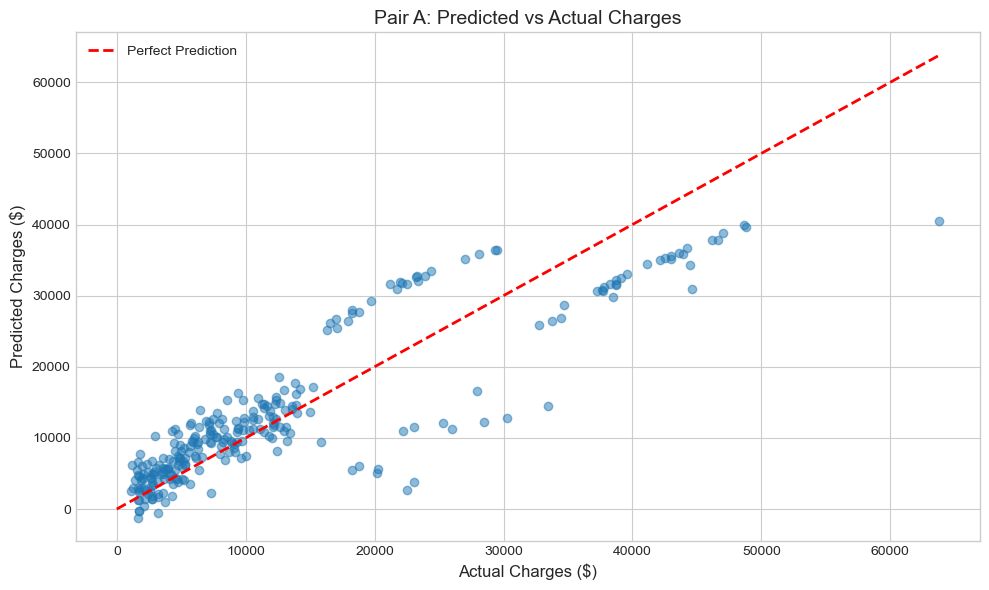

In [32]:
# PAIR A: Task 4 - Visualization
# Create a scatter plot of predicted vs actual values for your best model

# YOUR CODE HERE: Get predictions from your best model
# y_pred_best = ...

plt.figure(figsize=(10, 6))

# YOUR CODE HERE: Create scatter plot
plt.scatter(y_test_reg, predictions, alpha=0.5)

# Add perfect prediction line
max_val = max(y_test_reg.max(), predictions.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Charges ($)', fontsize=12)
plt.ylabel('Predicted Charges ($)', fontsize=12)
plt.title('Pair A: Predicted vs Actual Charges', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

### Task 5: Document Your Best Model

In [39]:
# PAIR A: Task 5 - Summary
# Fill in the comparison table with all models you tried

# Create a summary DataFrame
pair_a_results = {
    'Model': ['Linear Regression', 'Model 2 Name', 'Model 3 Name', 'Tuned Model'],
    'R² Score': [0.7836, 0.7835, 0.7403, 0.7836],  # Fill in your actual scores
    'RMSE ($)': [rmse_baseline, rmse_baseline_ridge, rmse_dt_baseline, rmse_lasso_baseline],  # Fill in your actual scores
}

pair_a_summary = pd.DataFrame(pair_a_results)

print("="*60)
print("PAIR A RESULTS: REGRESSION MODELS")
print("="*60)
print(pair_a_summary.to_string(index=False))
print("="*60)
print(f"\n🏆 BEST MODEL: [Fill in]")
print(f"   R² Score: [Fill in]")
print(f"   RMSE: $[Fill in]")

PAIR A RESULTS: REGRESSION MODELS
            Model  R² Score    RMSE ($)
Linear Regression    0.7836 5796.284659
     Model 2 Name    0.7835 5796.979691
     Model 3 Name    0.7403 6441.553796
      Tuned Model    0.7836 5796.649553

🏆 BEST MODEL: [Fill in]
   R² Score: [Fill in]
   RMSE: $[Fill in]


**Pair A: Why did your best model win? Write your explanation here:**

*[Your explanation]*

---

# Section D: PAIR B - Classification Challenge

## 🎯 Your Mission: Predict High-Cost Patients

**Target:** `high_cost` (0 = below median charges, 1 = above median charges)

**Metrics to report:**
- Accuracy
- Precision
- Recall
- F1-Score

**Models to try:**
- Logistic Regression (baseline)
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Naive Bayes
- Decision Tree Classifier
- Random Forest Classifier

**Remember:** KNN and SVM need scaled data! Use `X_train_scaled_df` and `X_test_scaled_df` for those models.

---

### Task 1: Build a Baseline Logistic Regression

In [56]:
# PAIR B: Task 1 - Baseline Logistic Regression
# Use X_train_scaled_df (or X_train_clf), y_train_clf for training
# Use X_test_scaled_df (or X_test_clf), y_test_clf for testing

# YOUR CODE HERE: Create and train a LogisticRegression model
logic_model = LogisticRegression(random_state=42, max_iter=1000)
logic_model.fit(X_train_scaled_df, y_train_clf)


# YOUR CODE HERE: Make predictions on test set
y_pred_baseline = logic_model.predict(X_test_scaled_df)


# YOUR CODE HERE: Calculate accuracy, precision, recall, F1
accuracy_baseline = accuracy_score(y_test_clf, y_pred_baseline)
precision_baseline = precision_score(y_test_clf, y_pred_baseline)
recall_baseline = recall_score(y_test_clf, y_pred_baseline)
f1_baseline = f1_score(y_test_clf, y_pred_baseline)

# Print results
print("="*50)
print("BASELINE: Logistic Regression")
print("="*50)
print(f"Accuracy:  {accuracy_baseline:.4f}")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall:    {recall_baseline:.4f}")
print(f"F1-Score:  {f1_baseline:.4f}")
print("="*50)

BASELINE: Logistic Regression
Accuracy:  0.9142
Precision: 0.8898
Recall:    0.9262
F1-Score:  0.9076


### Task 2: Try At Least 2 Other Classification Models

Pick from: **KNN, SVM, Naive Bayes, Decision Tree, Random Forest**

Remember: KNN and SVM need scaled data!

In [42]:
# PAIR B: Task 2 - Model 2 (e.g., KNN or SVM)
# Remember: These need SCALED data!

# Example for KNN:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled_df, y_train_clf)

# Example for SVM:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled_df, y_train_clf)

# YOUR CODE HERE



SVC(random_state=42)

In [43]:
# PAIR B: Task 2 - Model 3 (e.g., Naive Bayes or Random Forest)

# Example for Naive Bayes (doesn't need scaled data):
nb_model = GaussianNB()
nb_model.fit(X_train_clf, y_train_clf)

# Example for Random Forest (doesn't need scaled data):
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_clf, y_train_clf)

# YOUR CODE HERE



RandomForestClassifier(random_state=42)

In [ ]:
# PAIR B: Task 2 - (Optional) Model 4

# YOUR CODE HERE
dtc_model = DecisionTreeClassifier()
dtc_model.fit(X_train_clf, y_train_clf)



### Task 3: Tune Your Best Model with GridSearchCV

In [ ]:
# PAIR B: Task 3 - Hyperparameter Tuning
# Choose your best performing model and tune its hyperparameters

# Example for KNN:
# param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}

# Example for SVM:
# param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}

# Example for Random Forest:
# param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 7, None]}

# Example for Decision Tree:
# param_grid = {'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 10]}

# YOUR CODE HERE



### Task 4: Create Confusion Matrix Visualization

In [ ]:
# PAIR B: Task 4 - Confusion Matrix
# Create a confusion matrix for your best model

# YOUR CODE HERE: Get predictions from your best model
# y_pred_best_clf = ...

# Create confusion matrix
# cm = confusion_matrix(y_test_clf, y_pred_best_clf)

plt.figure(figsize=(8, 6))

# YOUR CODE HERE: Display confusion matrix
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Cost', 'High Cost'])
# disp.plot(cmap='Blues', ax=plt.gca())

plt.title('Pair B: Confusion Matrix for Best Model', fontsize=14)
plt.tight_layout()
plt.show()

# Print classification report
# print("\nClassification Report:")
# print(classification_report(y_test_clf, y_pred_best_clf, target_names=['Low Cost', 'High Cost']))

### Task 5: Document Your Best Model

In [ ]:
# PAIR B: Task 5 - Summary
# Fill in the comparison table with all models you tried

# Create a summary DataFrame
pair_b_results = {
    'Model': ['Logistic Regression', 'Model 2 Name', 'Model 3 Name', 'Tuned Model'],
    'Accuracy': [0.0, 0.0, 0.0, 0.0],    # Fill in your actual scores
    'Precision': [0.0, 0.0, 0.0, 0.0],   # Fill in your actual scores
    'Recall': [0.0, 0.0, 0.0, 0.0],      # Fill in your actual scores
    'F1-Score': [0.0, 0.0, 0.0, 0.0],    # Fill in your actual scores
}

pair_b_summary = pd.DataFrame(pair_b_results)

print("="*70)
print("PAIR B RESULTS: CLASSIFICATION MODELS")
print("="*70)
print(pair_b_summary.to_string(index=False))
print("="*70)
print(f"\n🏆 BEST MODEL: [Fill in]")
print(f"   Accuracy:  [Fill in]")
print(f"   F1-Score:  [Fill in]")

**Pair B: Why did your best model win? Write your explanation here:**

*[Your explanation]*

---

# Section E: Group Discussion & Synthesis

## 🤝 Come Back Together as a Full Group

---

Now that both pairs have built their models, it's time to share and discuss!

### Share Your Results

Each pair should walk the group through:
- **What models did you try?**
- **Which one performed best and why do you think that is?**
- **What was your best score?** (R²/RMSE for regression, Accuracy/F1 for classification)
- **Any surprises or insights?**
- **How confident do you feel in your final model?**

---

### Review Each Other's Code

Take a few minutes to look at what the other pair built:
- What approach did they take?
- Did they try anything you didn't think of?
- Any suggestions or questions about their code?

---

### Discussion Questions

Talk through these as a group:

**1. Which task was harder - regression or classification? Why?**

*[Group discussion]*

**2. Did the same features seem to matter for both tasks? What patterns did you notice?**

*[Group discussion]*

**3. In a real healthcare setting, when would you want to predict exact cost (regression) vs just "high/low risk" (classification)?**

*[Group discussion]*

### Final Model Summary

Fill in your group's best results:

In [ ]:
# GROUP FINAL SUMMARY

print("="*70)
print("GROUP FINAL RESULTS")
print("="*70)
print("\n📊 REGRESSION (Predicting Charges)")
print("-"*40)
print(f"Best Model: [Fill in]")
print(f"R² Score:   [Fill in]")
print(f"RMSE:       $[Fill in]")

print("\n📊 CLASSIFICATION (Predicting High Cost)")
print("-"*40)
print(f"Best Model: [Fill in]")
print(f"Accuracy:   [Fill in]")
print(f"F1-Score:   [Fill in]")

print("\n" + "="*70)

---

# PART 3: Reflection & Wrap-Up

---

### Think About It

As you wrap up, consider these questions:

**What's one thing you understand better now than you did at the start of class?**

**What's one thing that's still confusing or you want to learn more about?**

**Looking at your final model summary above - how do you feel about the results? Would you trust these models in a real healthcare setting?**

---

## Great Work!

You've completed the Unit 3 ML Team Challenge!

**What you accomplished today:**
- Practiced explaining ML concepts (interview prep!)
- Built and compared multiple regression models
- Built and compared multiple classification models
- Learned how to convert regression → classification
- Used hyperparameter tuning to improve your models
- Collaborated with teammates and learned from each other

**These skills will be directly applicable to your capstone projects!**

---